In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Relative path keeps the notebook portable inside the repo
base_dir = os.path.join("..", "data", "seedling_dataset")

# Preprocessed image array and labels CSV
images = np.load(os.path.join(base_dir, "images.npy"))
labels = pd.read_csv(os.path.join(base_dir, "labels.csv"))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print(f"\nNumber of classes: {labels['Label'].nunique()}")
print(f"\nClass distribution:\n{labels['Label'].value_counts()}")



Images shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)

Number of classes: 12

Class distribution:
Label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Common wheat                 221
Maize                        221
Name: count, dtype: int64


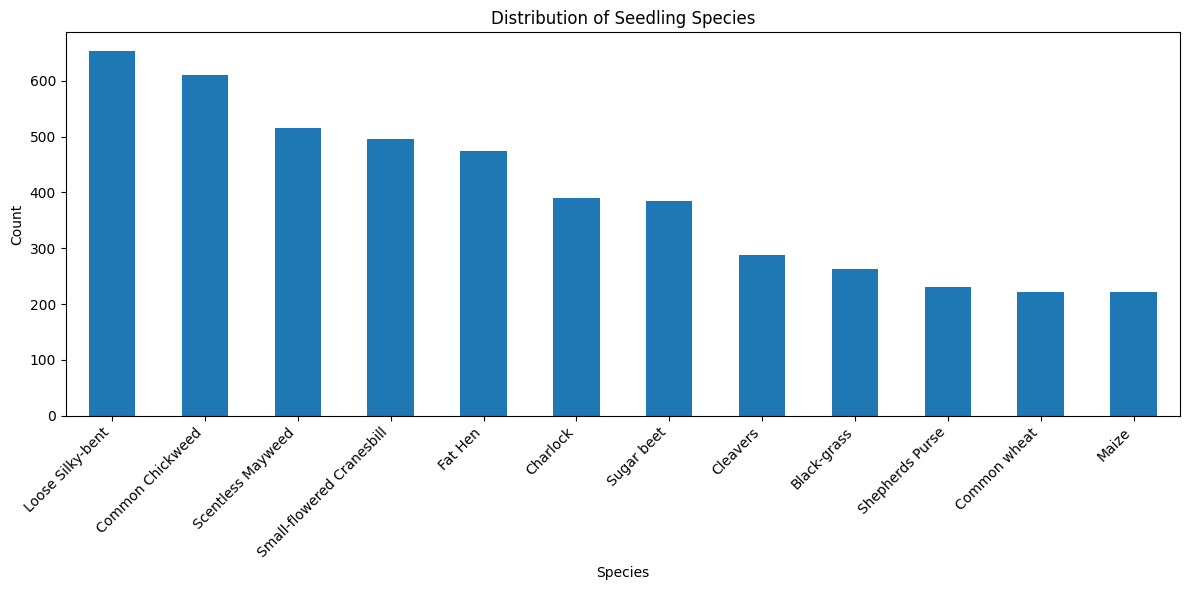

In [2]:
# Class distribution bar chart
plt.figure(figsize=(12, 6))
labels['Label'].value_counts().plot(kind='bar')
plt.title("Distribution of Seedling Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


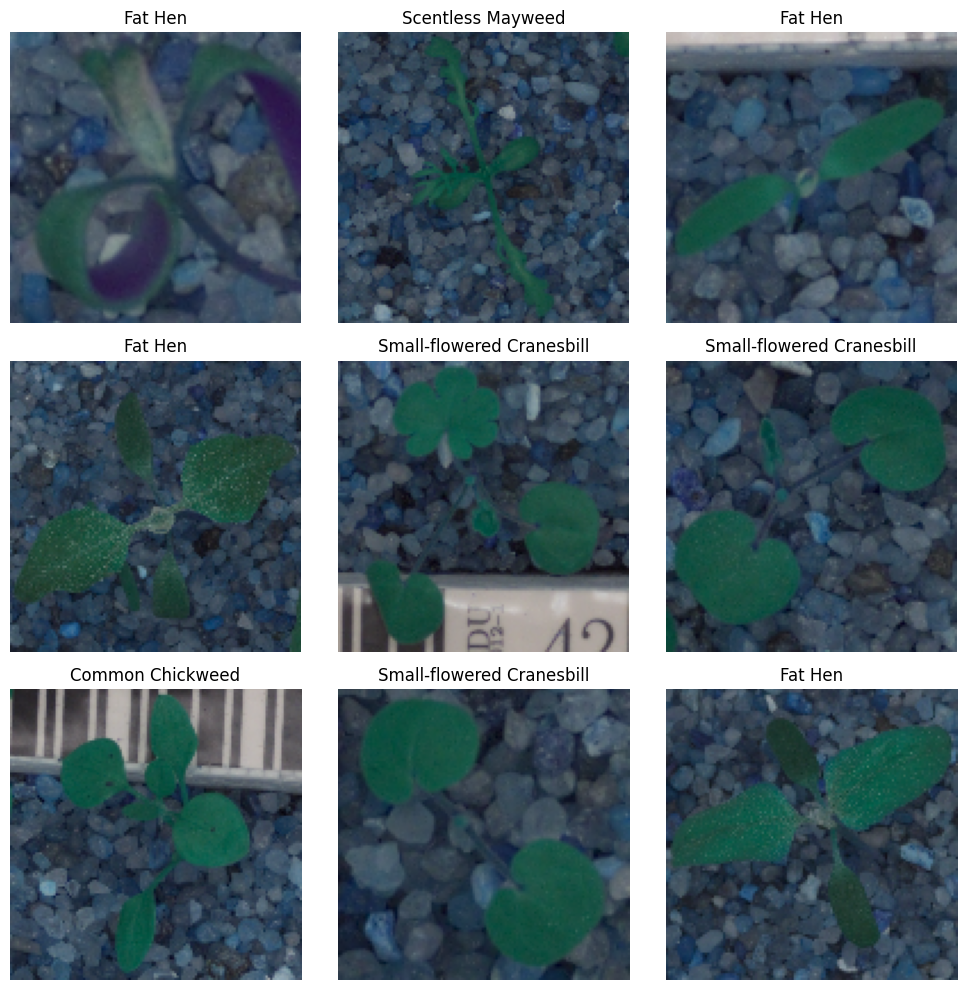

In [3]:
# Random sample of 9 raw images with their labels
plt.figure(figsize=(10, 10))

for i in range(9):
    idx = np.random.randint(0, len(images))
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[idx])
    # Use the label string rather than the full row
    plt.title(labels.iloc[idx]['Label'])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
# Data augmentation configuration
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


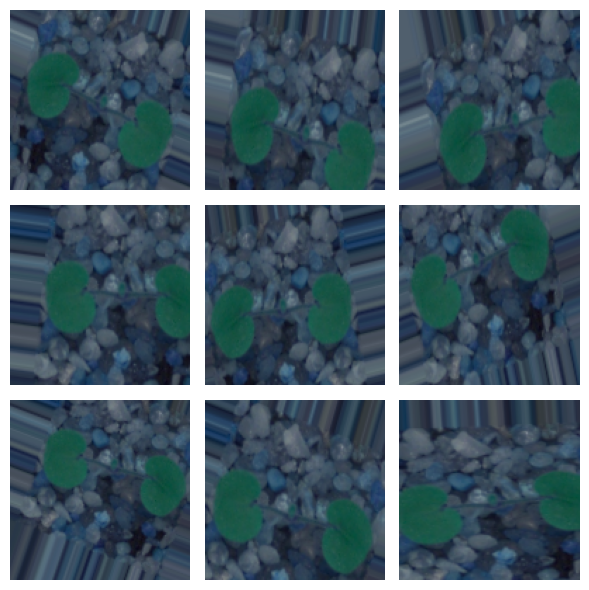

In [5]:
# Visualize augmented versions of a single sample image
sample = images[0].reshape((1,) + images[0].shape)

plt.figure(figsize=(6, 6))

for i in range(9):
    batch_iter = datagen.flow(sample, batch_size=1)
    img = next(batch_iter)[0]  # shape: (H, W, C)

    # Ensure image is uint8 for plt.imshow
    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            disp = (img * 255).astype("uint8")
        else:
            disp = img.astype("uint8")
    else:
        disp = img

    plt.subplot(3, 3, i + 1)
    plt.imshow(disp)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
# Normalize pixel values to [0, 1]
images = images.astype("float32") / 255.0


In [7]:
# Train / validation / test split with stratification on label column
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels['Label']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp['Label']
)

print("Train / Val / Test sizes:", len(X_train), len(X_val), len(X_test))


Train / Val / Test sizes: 3325 712 713


In [8]:
# Label encoding and one-hot encoding
label_encoder = LabelEncoder()

# Fit on ALL labels to ensure consistent class ordering
labels_encoded = label_encoder.fit_transform(labels['Label'])
class_names = list(label_encoder.classes_)
class_count = len(class_names)

print("Classes (in encoder order):", class_names)

# Encode split labels using the same encoder
y_train_idx = label_encoder.transform(y_train['Label'])
y_val_idx = label_encoder.transform(y_val['Label'])
y_test_idx = label_encoder.transform(y_test['Label'])

# One-hot encode targets
y_train_enc = to_categorical(y_train_idx, num_classes=class_count)
y_val_enc = to_categorical(y_val_idx, num_classes=class_count)
y_test_enc = to_categorical(y_test_idx, num_classes=class_count)


Classes (in encoder order): ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


In [9]:
# Save all datasets separately for review
save_dir = "saved_datasets"
os.makedirs(save_dir, exist_ok=True)

# Save image arrays (X datasets)
np.save(os.path.join(save_dir, "X_train.npy"), X_train)
np.save(os.path.join(save_dir, "X_val.npy"), X_val)
np.save(os.path.join(save_dir, "X_test.npy"), X_test)

# Save label DataFrames (y datasets)
y_train.to_csv(os.path.join(save_dir, "y_train.csv"), index=False)
y_val.to_csv(os.path.join(save_dir, "y_val.csv"), index=False)
y_test.to_csv(os.path.join(save_dir, "y_test.csv"), index=False)

# Save encoded label indices
np.save(os.path.join(save_dir, "y_train_idx.npy"), y_train_idx)
np.save(os.path.join(save_dir, "y_val_idx.npy"), y_val_idx)
np.save(os.path.join(save_dir, "y_test_idx.npy"), y_test_idx)

# Save one-hot encoded labels
np.save(os.path.join(save_dir, "y_train_enc.npy"), y_train_enc)
np.save(os.path.join(save_dir, "y_val_enc.npy"), y_val_enc)
np.save(os.path.join(save_dir, "y_test_enc.npy"), y_test_enc)

# Save class names for reference
class_names_df = pd.DataFrame({'class_names': class_names})
class_names_df.to_csv(os.path.join(save_dir, "class_names.csv"), index=False)

print(f"All datasets saved to '{save_dir}' directory:")
print("  - X_train.npy, X_val.npy, X_test.npy (image arrays)")
print("  - y_train.csv, y_val.csv, y_test.csv (label DataFrames)")
print("  - y_train_idx.npy, y_val_idx.npy, y_test_idx.npy (encoded indices)")
print("  - y_train_enc.npy, y_val_enc.npy, y_test_enc.npy (one-hot encoded)")
print("  - class_names.csv (class name reference)")

All datasets saved to 'saved_datasets' directory:
  - X_train.npy, X_val.npy, X_test.npy (image arrays)
  - y_train.csv, y_val.csv, y_test.csv (label DataFrames)
  - y_train_idx.npy, y_val_idx.npy, y_test_idx.npy (encoded indices)
  - y_train_enc.npy, y_val_enc.npy, y_test_enc.npy (one-hot encoded)
  - class_names.csv (class name reference)


In [10]:
# Simple CNN model (same structure, but now tied to class_count)
model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(class_count, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,868 (28.21 MB)

 Trainable params: 7,393,868 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Compute class weights using full encoded label vector
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_encoded),
    y=labels_encoded
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

# Train the model with augmentation, validation data, and class weights
history = model.fit(
    datagen.flow(X_train, y_train_enc, batch_size=32),
    epochs=50,
    validation_data=(X_val, y_val_enc),
    callbacks=[early_stop],
    class_weight=class_weights_dict
)


Class weights: {0: np.float64(1.5050697084917617), 1: np.float64(1.014957264957265), 2: np.float64(1.3792102206736354), 3: np.float64(0.6478450627386798), 4: np.float64(1.7911010558069382), 5: np.float64(0.8333333333333334), 6: np.float64(0.605249745158002), 7: np.float64(1.7911010558069382), 8: np.float64(0.7671188630490956), 9: np.float64(1.7135642135642135), 10: np.float64(0.7980510752688172), 11: np.float64(1.0281385281385282)}
Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.1432 - loss: 2.4354 - val_accuracy: 0.1334 - val_loss: 2.0986
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.1919 - loss: 2.1159 - val_accuracy: 0.2107 - val_loss: 1.8879
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.2376 - loss: 1.9962 - val_accuracy: 0.2767 - val_loss: 1.8046
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.2758 - loss: 1.8933 - val_accuracy: 0.3581 - val_loss: 1.6202
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/

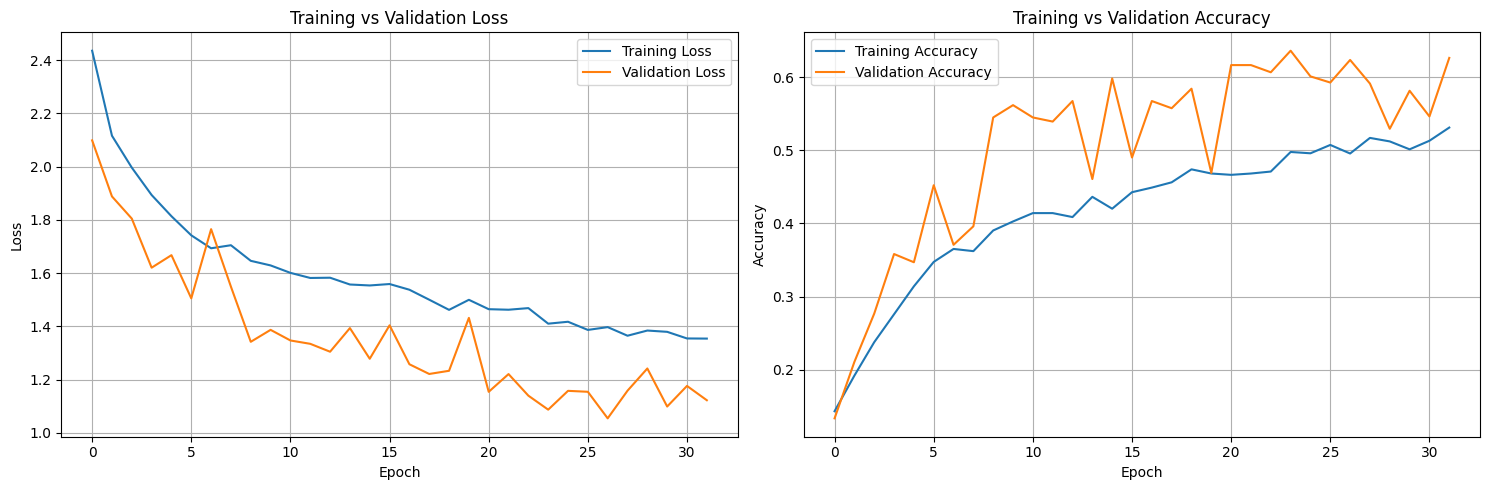

In [13]:
# Plot training history - Loss and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
MODEL PERFORMANCE METRICS
Test Accuracy:  0.6662 (66.62%)
Test Precision: 0.6962
Test Recall:    0.6662
Test F1-Score:  0.6645


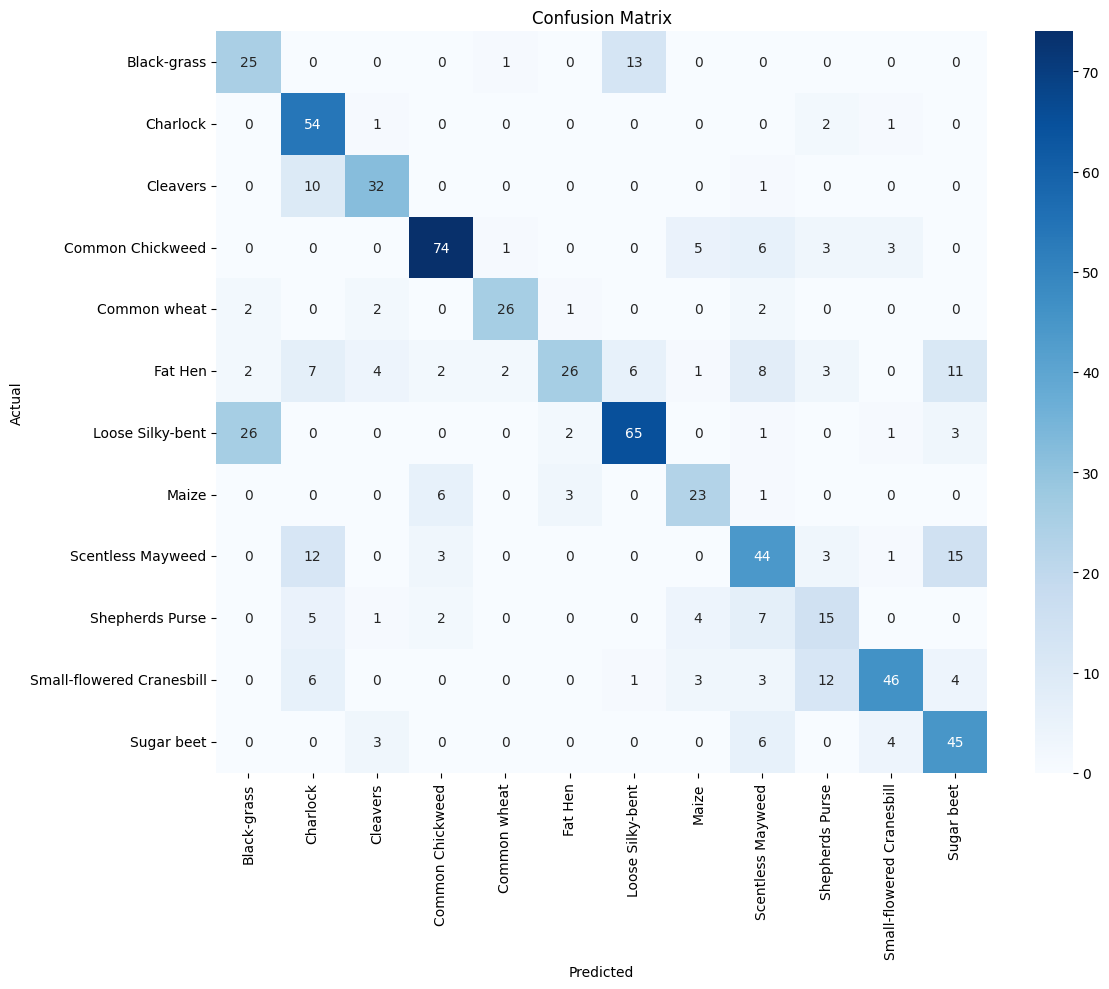


DETAILED CLASSIFICATION REPORT
                           precision    recall  f1-score   support

              Black-grass       0.45      0.64      0.53        39
                 Charlock       0.57      0.93      0.71        58
                 Cleavers       0.74      0.74      0.74        43
         Common Chickweed       0.85      0.80      0.83        92
             Common wheat       0.87      0.79      0.83        33
                  Fat Hen       0.81      0.36      0.50        72
         Loose Silky-bent       0.76      0.66      0.71        98
                    Maize       0.64      0.70      0.67        33
        Scentless Mayweed       0.56      0.56      0.56        78
          Shepherds Purse       0.39      0.44      0.42        34
Small-flowered Cranesbill       0.82      0.61      0.70        75
               Sugar beet       0.58      0.78      0.66        58

                 accuracy                           0.67       713
                macro avg   

In [14]:
# Model evaluation
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_enc, axis=1)

# Calculate metrics
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='weighted')
test_recall = recall_score(y_true, y_pred, average='weighted')
test_f1 = f1_score(y_true, y_pred, average='weighted')

print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")
print("=" * 60)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))


In [15]:
# Save model
model.save(os.path.join("..", "models", "seedling_classifier_model.keras"))
print("Model saved successfully as ../models/seedling_classifier_model.keras")


Model saved successfully as ../models/seedling_classifier_model.keras
